In [3]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import getpass
import glob

### Structure query

In [5]:
# set your API key before making the request
YOUR_API_KEY = getpass.getpass("Enter OpenET API Key Here:")
header = {"Authorization": YOUR_API_KEY}
# arguments to pass to API endpoint



Enter OpenET API Key Here: ········


### Request data

* Iterate through models and intervals
* Append model, eto source, interval, and date of extraction to standard files for queries to the `raster/timeseries/multipolygon` 

In [41]:
models = ['ensemble','disalexi','eemetric','geesebal','ptjpl','sims','ssebop']
eto_source = ['gridMET','cimis']
intervals = ["daily","monthly"]

In [39]:
today = date.today().strftime("%Y%m%d")

for model in models:
    print(model)
    for interval in intervals:
        print(f"\tstarting {interval} extraction") 
        # endpoint arguments
        
        args = {
            "date_range": [
                "2016-01-01",        # start date
                "2016-12-31"         # end date
            ],
            
            "interval": interval,     # frequency of data: daily or monthly
              "asset_id": "projects/openet-training-assets/assets/cadwr/ca_delta_footprints", # < google earth engine asset
              "attributes": [
                "site"],                       # Must include a unique identifier for each polygon
            "reducer": "mean",       # Pixel aggregation method within each polygon
            "model": model,     # Model options: Ensemble, geeSEBAL, SSEBop, SIMS, DisALEXI, PTJPL, or eeMETRIC.
            "overpass":False,        # Optional parameter for daily timesteps return only satellite overpass dates
            "variable": "ET",        # Variable options: ET, EToF, ETo, PR, NDVI
            "reference_et": eto_source[0], # ETo options: CIMiS, gridMET
            "units": "mm",           # Unit options: mm, in
            "version": 2.1
        }
        # query the api
        resp = requests.post(
            headers=header,
            json=args,
            url="https://openet-api.org/raster/timeseries/multipolygon"
            )
        output = resp.json()
        time.sleep(2)

        # covert to a dataframe
        df = pd.read_csv(output["url"], parse_dates=["time"])
        df["time"] = pd.to_datetime(df["time"])
        df.set_index("time", inplace=True)
        print('\tfile saved to: \n\t\t'+f'multi_polygon/openet_standard_multi_polygon_{model}_{eto_source[0]}_{today}.csv')
        df.to_csv(f'multi_polygon/openet_standard_multi_polygon_{interval}_{model}_{eto_source[0]}_{today}.csv')



eemetric
	starting daily extraction
	file saved to: 
		multi_polygon/openet_standard_multi_polygon_eemetric_gridMET_20260916.csv
	starting monthly extraction
	file saved to: 
		multi_polygon/openet_standard_multi_polygon_eemetric_gridMET_20260916.csv
geesebal
	starting daily extraction
	file saved to: 
		multi_polygon/openet_standard_multi_polygon_geesebal_gridMET_20260916.csv
	starting monthly extraction
	file saved to: 
		multi_polygon/openet_standard_multi_polygon_geesebal_gridMET_20260916.csv
ptjpl
	starting daily extraction
	file saved to: 
		multi_polygon/openet_standard_multi_polygon_ptjpl_gridMET_20260916.csv
	starting monthly extraction
	file saved to: 
		multi_polygon/openet_standard_multi_polygon_ptjpl_gridMET_20260916.csv
sims
	starting daily extraction
	file saved to: 
		multi_polygon/openet_standard_multi_polygon_sims_gridMET_20260916.csv
	starting monthly extraction
	file saved to: 
		multi_polygon/openet_standard_multi_polygon_sims_gridMET_20260916.csv
ssebop
	starting 

## Inspect Standard Files to Verify relative to prior ground-based measurment comparison

In [13]:
def assign_dt(df,datetime_col):
    '''
    inputs:
    df: variable name of input dataframe [pandas dataframe]
    datetime_col: column header for date time [string]
    returns:
    outdf: a dataframe with datetime_col set to index in datetime format
    '''
    outdf = df.copy()
    outdf[datetime_col] = pd.to_datetime(outdf[datetime_col])
    outdf.set_index(datetime_col,inplace=True)
    return outdf

ensemble US-Bi1


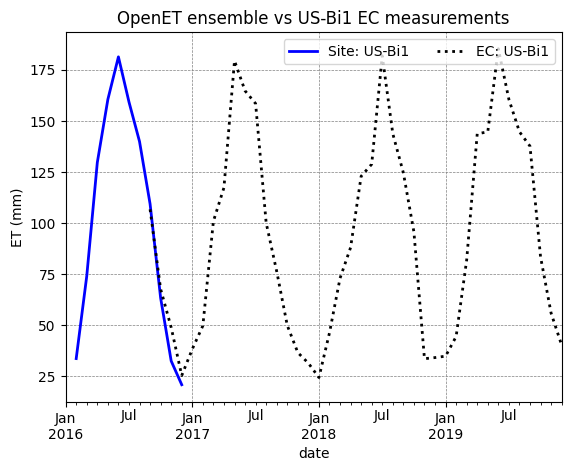

disalexi US-Bi1


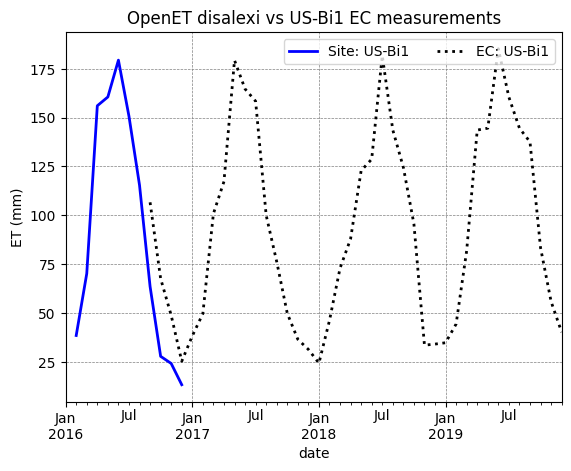

eemetric US-Bi1


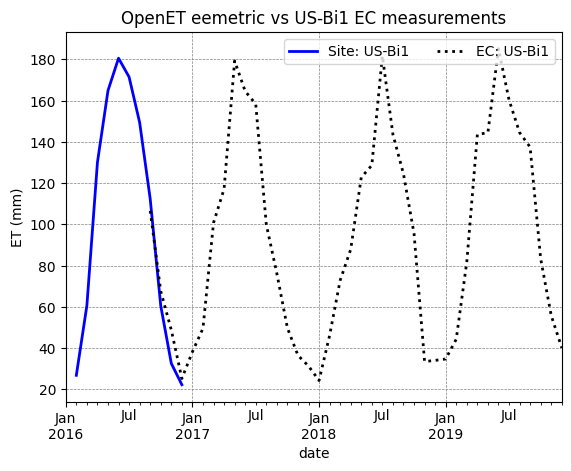

geesebal US-Bi1


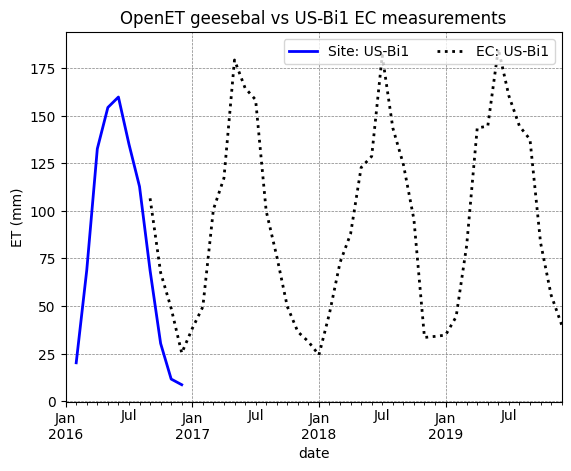

ptjpl US-Bi1


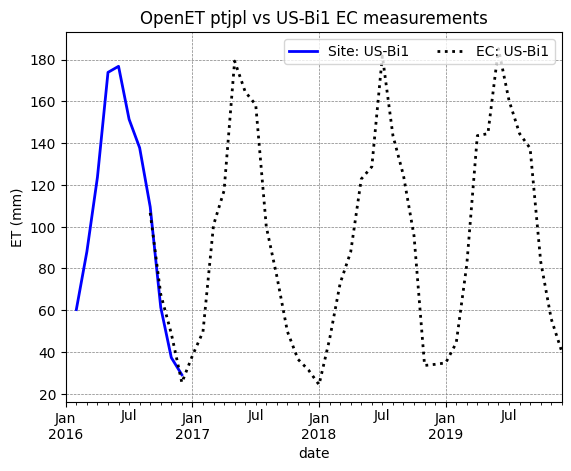

sims US-Bi1


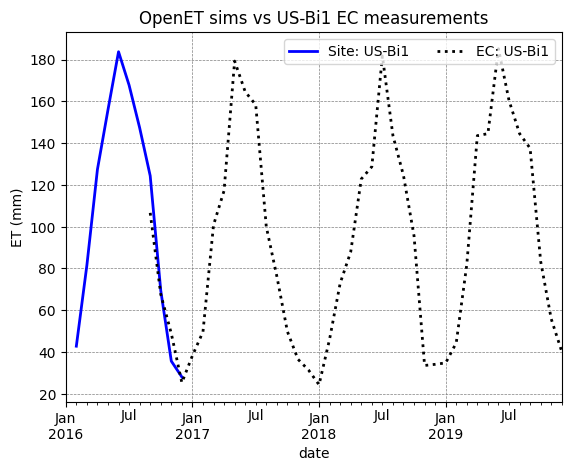

ssebop US-Bi1


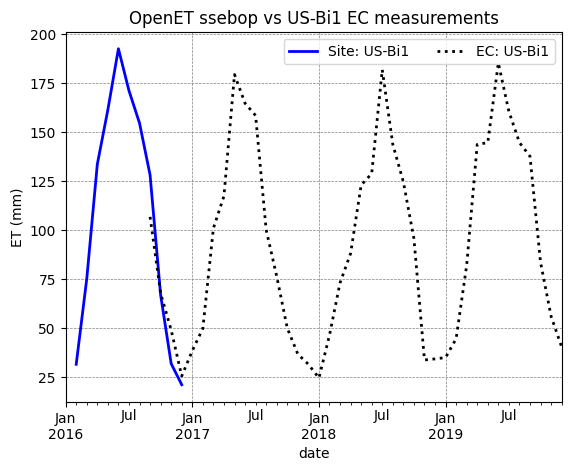

ensemble US-Tw3


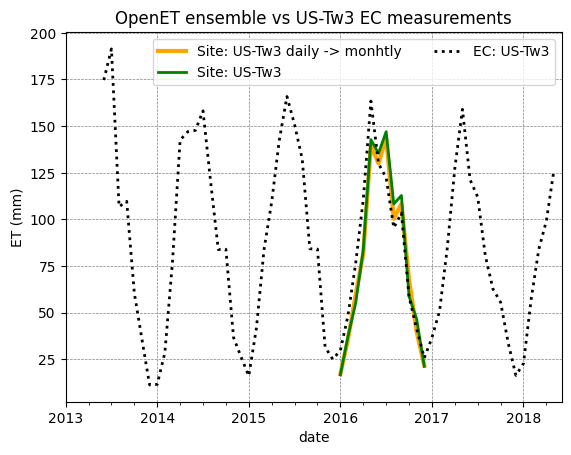

disalexi US-Tw3


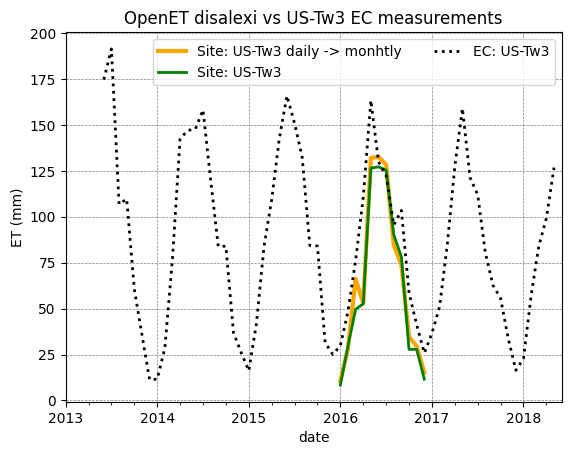

eemetric US-Tw3


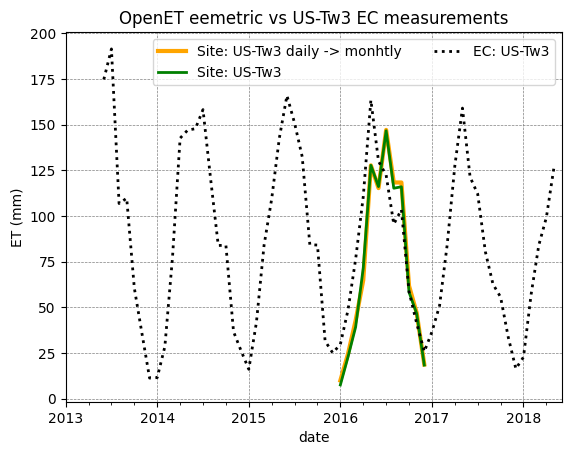

geesebal US-Tw3


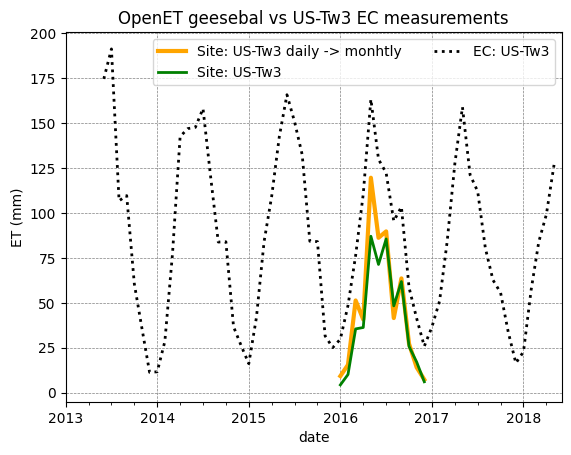

ptjpl US-Tw3


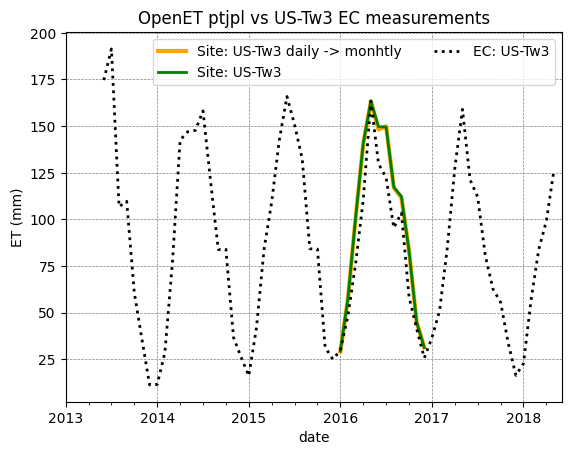

sims US-Tw3


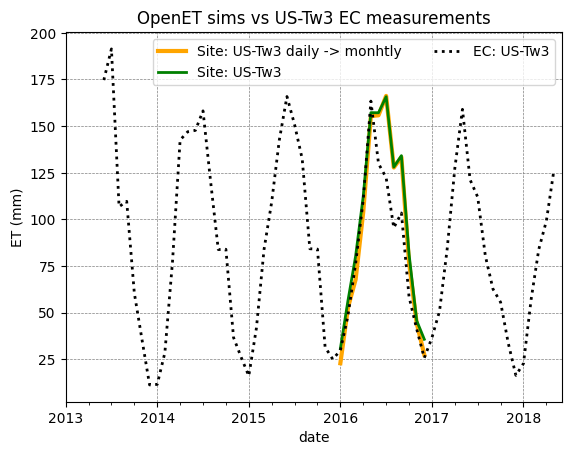

ssebop US-Tw3


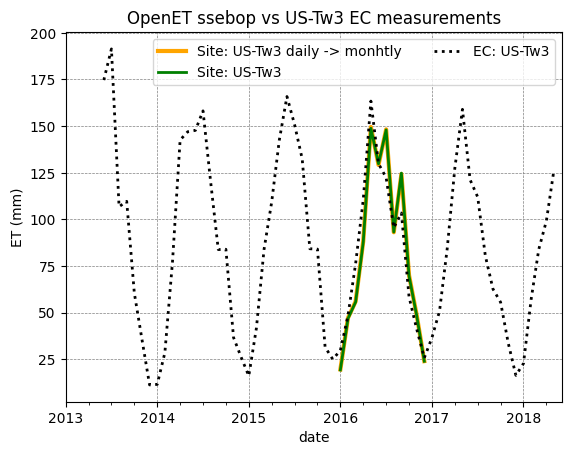

ensemble US-Twt


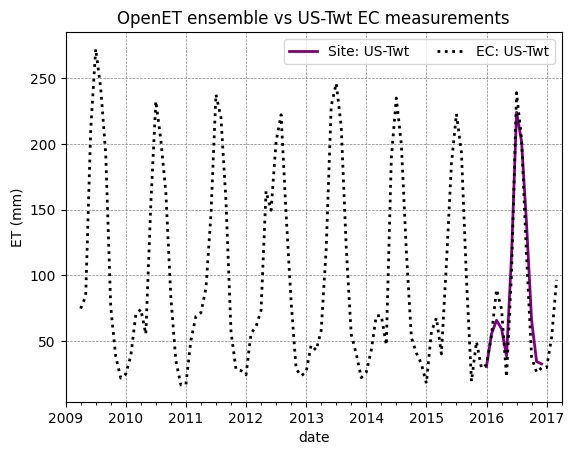

disalexi US-Twt


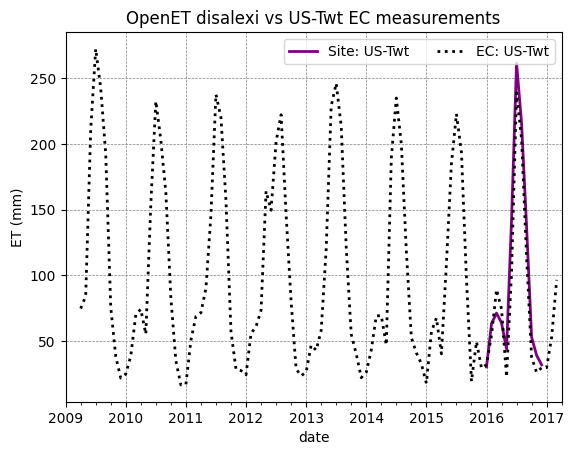

eemetric US-Twt


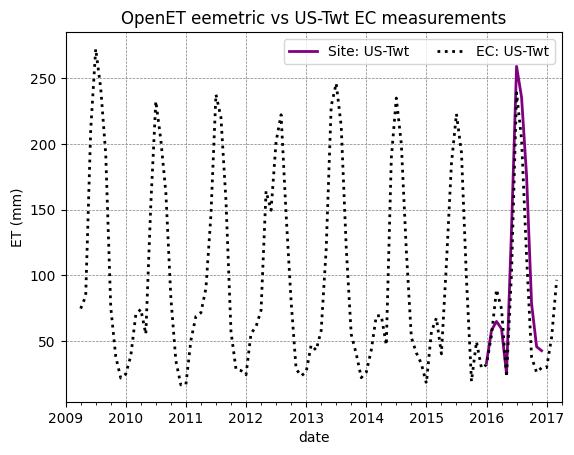

geesebal US-Twt


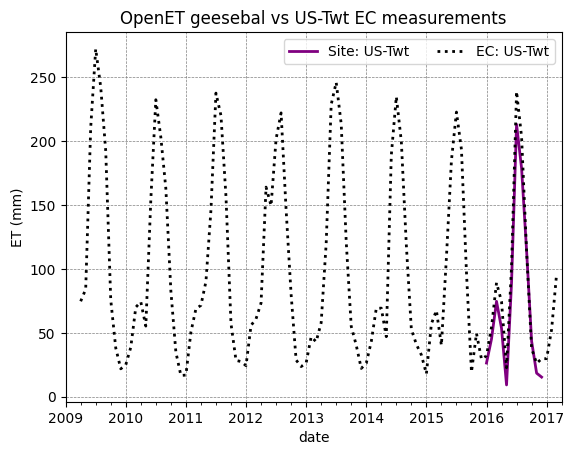

ptjpl US-Twt


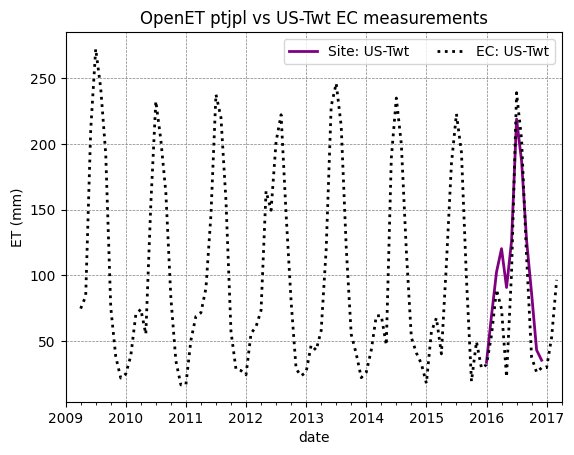

sims US-Twt


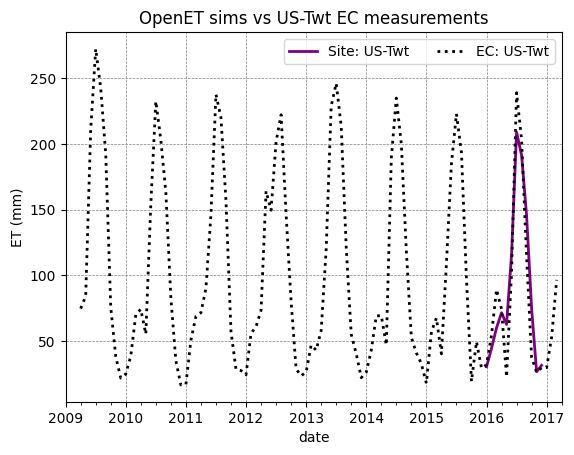

ssebop US-Twt


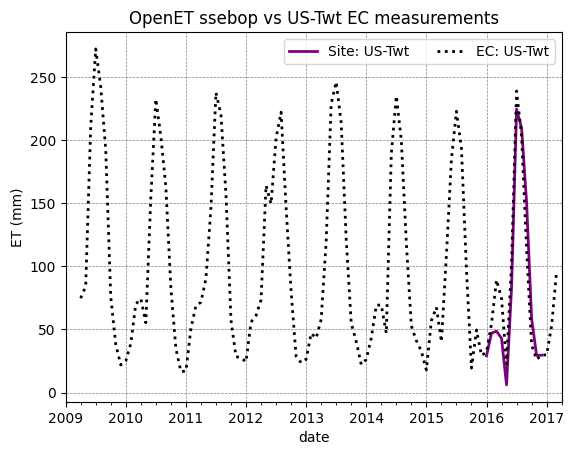

In [42]:
# Read in US-TW3 dataset
daily_ground_data = pd.read_csv('ground_et_measurements/US-Tw3_daily_data.csv')
daily_ec_file = assign_dt(daily_ground_data,'date')
daily_ec_file = daily_ec_file.loc[(daily_ec_file.index>='2016-01-01')&(daily_ec_file.index<='2016-12-31')]
# Assign date of reference dataset
date_of_extraction = '20260916'
colors =['blue','orange','green','purple']
# plot figures to verify reference dataset is of good quality
i=0

for id_value in df["site"].unique():
    
    for model in models[0:]:
        if id_value != "US-Bi2":
            print(model,id_value)
            df_day = pd.read_csv(f'multi_polygon/openet_standard_multi_polygon_daily_{model}_gridMET_{date_of_extraction}.csv')
            df_day["time"] = pd.to_datetime(df_day["time"])
            df_month =pd.read_csv(f'multi_polygon/openet_standard_multi_polygon_monthly_{model}_gridMET_{date_of_extraction}.csv')    
            df_month["time"] = pd.to_datetime(df_month["time"])
            # Read in Monthly CSV Files
            monthly_ec_file = f"ground_et_measurements/{id_value}_monthly_data.csv"
            ec_df = pd.read_csv(monthly_ec_file)
            ec_df["date"] = pd.to_datetime(ec_df["date"])
            #Set date of each timestep to be 1st day of each month
            ec_df['date'] = ec_df['date'] - pd.offsets.MonthEnd() + pd.offsets.MonthBegin()
            df_day_filtered = df_day[df_day["site"] == id_value]
            df_day_filtered = df_day_filtered.loc[(df_day_filtered['time'] > ec_df.date.values[0]) & (df_day_filtered['time'] < ec_df.date.values[-1])]
            df_month_filtered = df_month[df_month["site"] == id_value]
            df_month_filtered = df_month_filtered.loc[(df_month_filtered['time'] > ec_df.date.values[0]) & (df_month_filtered['time'] < ec_df.date.values[-1])]

            df_day_filtered.set_index('time', inplace=True)
            df_month_filtered.set_index('time', inplace=True)
            ec_df.set_index('date', inplace=True)

            # plot the ET values for this "id"
            if id_value == 'US-Tw3':
                    df_day_filtered["et"].resample("ME").sum().plot(label=f"Site: {id_value} daily -> monhtly ",linestyle='-',lw=3,c='orange')
            df_month_filtered["et"].plot(label=f"Site: {id_value}",linestyle='-',lw=2,c=colors[i])
            ec_df["ET_corr"].plot(label=f"EC: {id_value}",linestyle=':',c='k',lw=2)

            plt.title(f"OpenET {model} vs {id_value} EC measurements")
            plt.ylabel("ET (mm)")
            plt.grid(True, linestyle="--", linewidth=0.5, color="grey")
            plt.legend(ncol=2,loc='upper right')
            # plt.savefig(f'figures/OpenET_vs_EC_comp_+{id_value}.png') # un comment line if you want to save a figure
            plt.show()
    i+=1
